# Spindown Analysis
Extracts the spin decay time τ from LES YAW monitor data using the Hilbert transform.

**Method:** bandpass filter → Hilbert transform → instantaneous frequency → exponential fit  
**Model:** f(t) = A · exp(−t/τ)  (free spindown, no steady-state offset)

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timezone
from scipy.signal import decimate, butter, sosfiltfilt, hilbert
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d

In [51]:
FILENAME_PIT = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_Pit/Y1_RDS-LES_PIT_OUT_DQ_1463340640_1463429200.0.h5'
FILENAME_YAW = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/LES_Pit/Y1_RDS-LES_YAW_OUT_DQ_1463421840_1463425440.h5'
FILENAME_V1  = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/electrodes/Y1_RDS-OUTS_V1_OUT_DQ_1463340640_1463429200.0.h5'

# GPS → UTC: GPS epoch is Jan 6 1980; 18 leap seconds as of 2025
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

def dt_to_gps(dt):
    return dt.timestamp() - GPS_UNIX_OFFSET

In [52]:
with h5py.File(FILENAME_PIT, 'r') as f:
    FS        = float(f.attrs['sample_rate'])
    gps_start = float(f.attrs['gps_start'])
    gps_end   = float(f.attrs['gps_end'])
    n_total   = f['data'].shape[0]

print(f"Rate:     {FS} Hz")
print(f"Samples:  {n_total:,}  ({n_total / FS / 3600:.2f} h)")
print(f"Start:    {gps_to_dt(gps_start)}")
print(f"End:      {gps_to_dt(gps_end)}")

Rate:     1024.0 Hz
Samples:  90,316,800  (24.50 h)
Start:    2026-05-20 19:30:22+00:00
End:      2026-05-21 20:06:22+00:00


## 2. Overview: Full Time Series
Strided read (every 256th sample → 4 Hz) for fast visual inspection across the full 24h window.  
Use this to find the spindown region, then set `RING_START` / `RING_END` below.

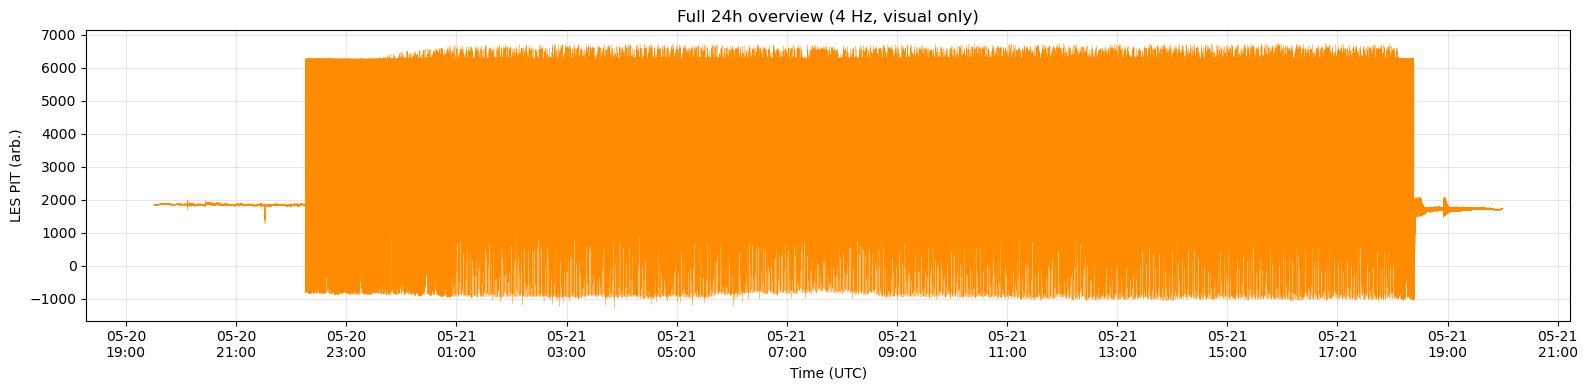

In [53]:
# Strided read — no anti-alias filter, for visual inspection only
STRIDE = 256  # 1024 Hz → 4 Hz
t_ov, y_ov = [], []

with h5py.File(FILENAME_PIT, 'r') as f:
    segs = f['segments/gps_start'][:].astype(np.float64)
    idxs = f['segments/index_start'][:].astype(np.int64)
    lens = f['segments/length'][:].astype(np.int64)
    dset = f['data']
    for gps0, ix, n in zip(segs, idxs, lens):
        y_seg = dset[ix : ix + n : STRIDE].astype(np.float32)
        t_seg = gps0 + np.arange(len(y_seg)) * STRIDE / 1024.0
        t_ov.append(t_seg)
        y_ov.append(y_seg)

t_ov = np.concatenate(t_ov)
y_ov = np.concatenate(y_ov)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot([gps_to_dt(t) for t in t_ov], y_ov, linewidth=0.2, color='darkorange')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('LES PIT (arb.)')
ax.set_title('Full 24h overview (4 Hz, visual only)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
def load_channel(filename, fs_out=64.0, gps_t0=None, gps_t1=None):
    """Load an HDF5 channel, decimate to fs_out Hz. Optionally restrict to [gps_t0, gps_t1]."""
    t_list, y_list = [], []
    with h5py.File(filename, 'r') as f:
        fs   = float(f.attrs['sample_rate'])
        segs = f['segments/gps_start'][:].astype(np.float64)
        idxs = f['segments/index_start'][:].astype(np.int64)
        lens = f['segments/length'][:].astype(np.int64)
        dset = f['data']
        for gps0, ix, n in zip(segs, idxs, lens):
            gps1 = gps0 + n / fs
            if gps_t0 and gps1 < gps_t0: continue
            if gps_t1 and gps0 > gps_t1: continue
            seg = dset[ix : ix + n].astype(np.float64)
            seg = decimate(decimate(seg, 4, zero_phase=True), 4, zero_phase=True)  # ÷16 → 64 Hz
            t_seg = gps0 + np.arange(len(seg)) / fs_out
            t_list.append(t_seg)
            y_list.append(seg)
    t = np.concatenate(t_list)
    y = np.concatenate(y_list)
    if gps_t0: mask = t >= gps_t0; t, y = t[mask], y[mask]
    if gps_t1: mask = t <= gps_t1; t, y = t[mask], y[mask]
    return t, y

# ── Set window based on overview plot above ───────────────────────────────────
# Spindown begins ~17:45 UTC; load from 16:00 to give ~2h pre-decay context
RING_START = datetime(2026, 5, 21, 16, 0, 0, tzinfo=timezone.utc)
RING_END   = datetime(2026, 5, 21, 20, 0, 0, tzinfo=timezone.utc)
# ─────────────────────────────────────────────────────────────────────────────

gps_t0 = dt_to_gps(RING_START)
gps_t1 = dt_to_gps(RING_END)

FS_RING = 64.0
t_pit, y_pit = load_channel(FILENAME_PIT, FS_RING, gps_t0, gps_t1)
t_yaw, y_yaw = load_channel(FILENAME_YAW, FS_RING)

print(f"PIT: {len(y_pit):,} samples  {gps_to_dt(t_pit[0])} → {gps_to_dt(t_pit[-1])}")
print(f"YAW: {len(y_yaw):,} samples  {gps_to_dt(t_yaw[0])} → {gps_to_dt(t_yaw[-1])}")

PIT: 921,601 samples  2026-05-21 16:00:00+00:00 → 2026-05-21 20:00:00+00:00
YAW: 230,400 samples  2026-05-21 18:03:42+00:00 → 2026-05-21 19:03:41.984375+00:00


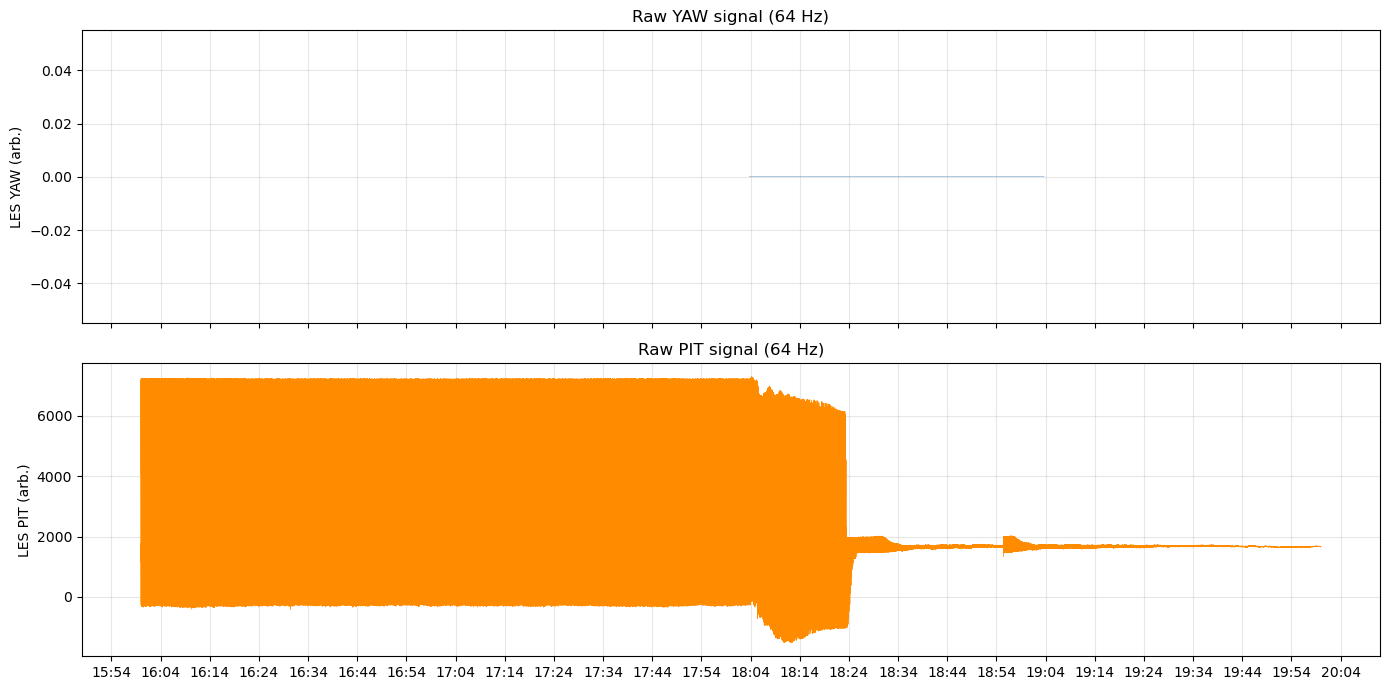

In [55]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot([gps_to_dt(t) for t in t_yaw], y_yaw, linewidth=0.3, color='steelblue')
axes[0].set_ylabel('LES YAW (arb.)')
axes[0].set_title('Raw YAW signal (64 Hz)')
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_pit], y_pit, linewidth=0.3, color='darkorange')
axes[1].set_ylabel('LES PIT (arb.)')
axes[1].set_title('Raw PIT signal (64 Hz)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bandpass Filter
Zero-phase Butterworth bandpass to isolate the spin signal.  
Low cut removes DC drift; high cut removes noise above the spin frequency range.

In [56]:
# ── Adjust if spin frequency range is different ───────────────────────────────
F_LOW  = 0.005  # Hz – removes DC drift; low enough to track spin down to near-zero
F_HIGH = 6.0    # Hz – above the 4 Hz electrode drive frequency
# ─────────────────────────────────────────────────────────────────────────────

sos     = butter(4, [F_LOW, F_HIGH], btype='bandpass', fs=FS_RING, output='sos')
y_yaw_f = sosfiltfilt(sos, y_yaw)
y_pit_f = sosfiltfilt(sos, y_pit)
print(f"Bandpass applied: {F_LOW}–{F_HIGH} Hz")

Bandpass applied: 0.005–6.0 Hz


## 4. Hilbert Transform: Instantaneous Amplitude and Frequency
The analytic signal gives the amplitude envelope and instantaneous phase.  
Instantaneous frequency = dφ/dt / (2π).  
A uniform smoothing filter removes sample-to-sample noise.

In [60]:
def hilbert_freq(y_filt, fs, smooth_sec=30.0):
    """Return (inst_freq, envelope, dt_half) — all arrays length N-1, aligned."""
    analytic  = hilbert(y_filt)
    envelope  = np.abs(analytic)
    phase     = np.unwrap(np.angle(analytic))
    dt        = 1.0 / fs
    inst_freq = np.diff(phase) / (2 * np.pi * dt)
    win       = max(1, int(smooth_sec * fs))
    # trim envelope to N-1 so it aligns with inst_freq
    return (uniform_filter1d(inst_freq,      size=win),
            uniform_filter1d(envelope[:-1],  size=win),
            dt / 2)

# ── Smoothing window ──────────────────────────────────────────────────────────
SMOOTH_SEC = 30.0
# ─────────────────────────────────────────────────────────────────────────────

freq_yaw, env_yaw, dt_half = hilbert_freq(y_yaw_f, FS_RING, SMOOTH_SEC)
freq_pit, env_pit, _       = hilbert_freq(y_pit_f, FS_RING, SMOOTH_SEC)

t_freq_yaw = t_yaw[:-1] + dt_half
t_freq_pit = t_pit[:-1] + dt_half

print(f"Array lengths — freq: {len(freq_pit)}, envelope: {len(env_pit)}  (should match)")
print(f"YAW freq range: {freq_yaw.min():.3f} – {freq_yaw.max():.3f} Hz")
print(f"PIT freq range: {freq_pit.min():.3f} – {freq_pit.max():.3f} Hz")

Array lengths — freq: 921600, envelope: 921600  (should match)
YAW freq range: 0.000 – 0.000 Hz
PIT freq range: 0.039 – 6.996 Hz


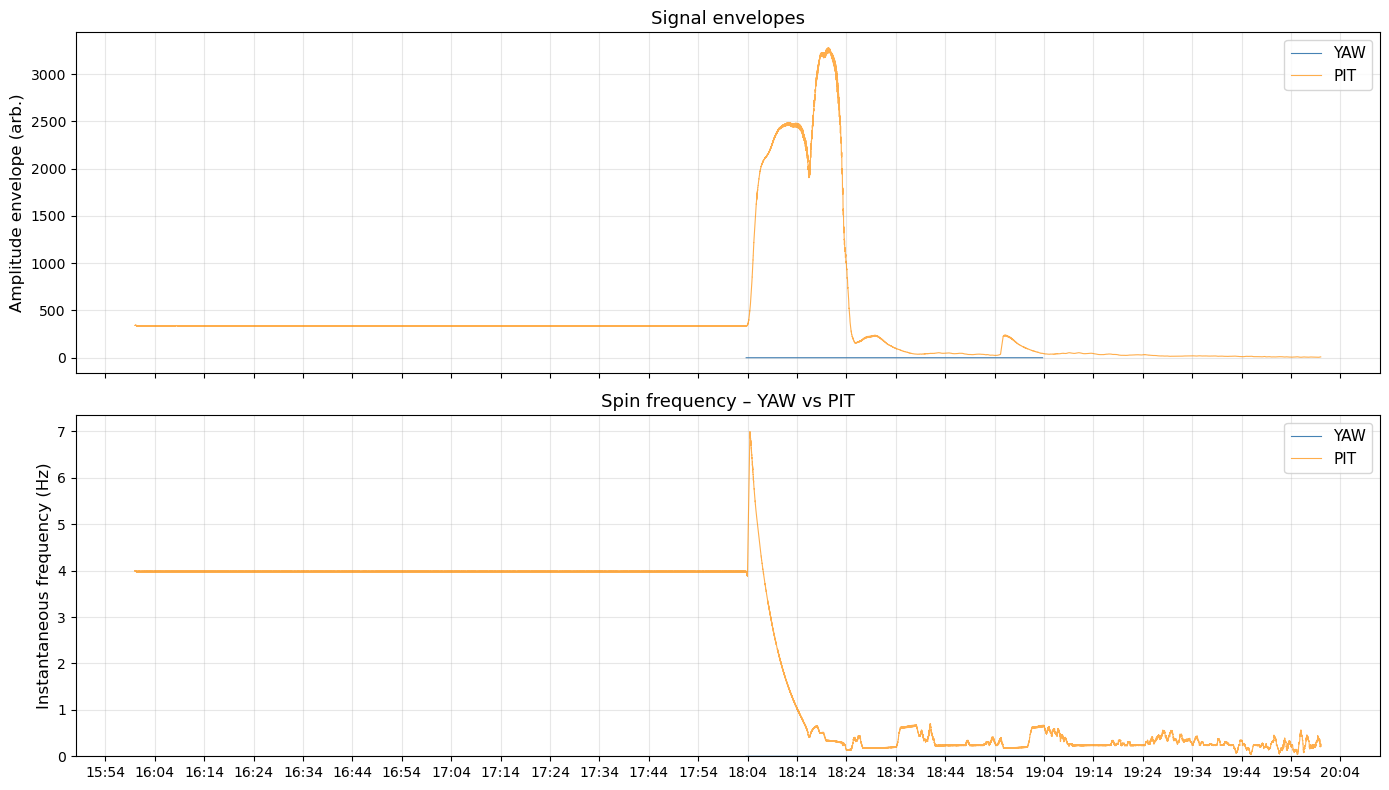

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# env arrays are now N-1 (trimmed), so use t_freq_ for both panels
axes[0].plot([gps_to_dt(t) for t in t_freq_yaw], env_yaw, linewidth=0.8,
             color='steelblue', label='YAW')
axes[0].plot([gps_to_dt(t) for t in t_freq_pit], env_pit, linewidth=0.8,
             color='darkorange', alpha=0.7, label='PIT')
axes[0].set_ylabel('Amplitude envelope (arb.)', fontsize=12)
axes[0].set_title('Signal envelopes', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot([gps_to_dt(t) for t in t_freq_yaw], freq_yaw, linewidth=0.8,
             color='steelblue', label='YAW')
axes[1].plot([gps_to_dt(t) for t in t_freq_pit], freq_pit, linewidth=0.8,
             color='darkorange', alpha=0.7, label='PIT')
axes[1].set_ylabel('Instantaneous frequency (Hz)', fontsize=12)
axes[1].set_title('Spin frequency – YAW vs PIT', fontsize=13)
axes[1].set_ylim(bottom=0)
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Drive-off (sinusoid):  2026-05-21 18:03:59.796875+00:00  (GPS 1463421858)


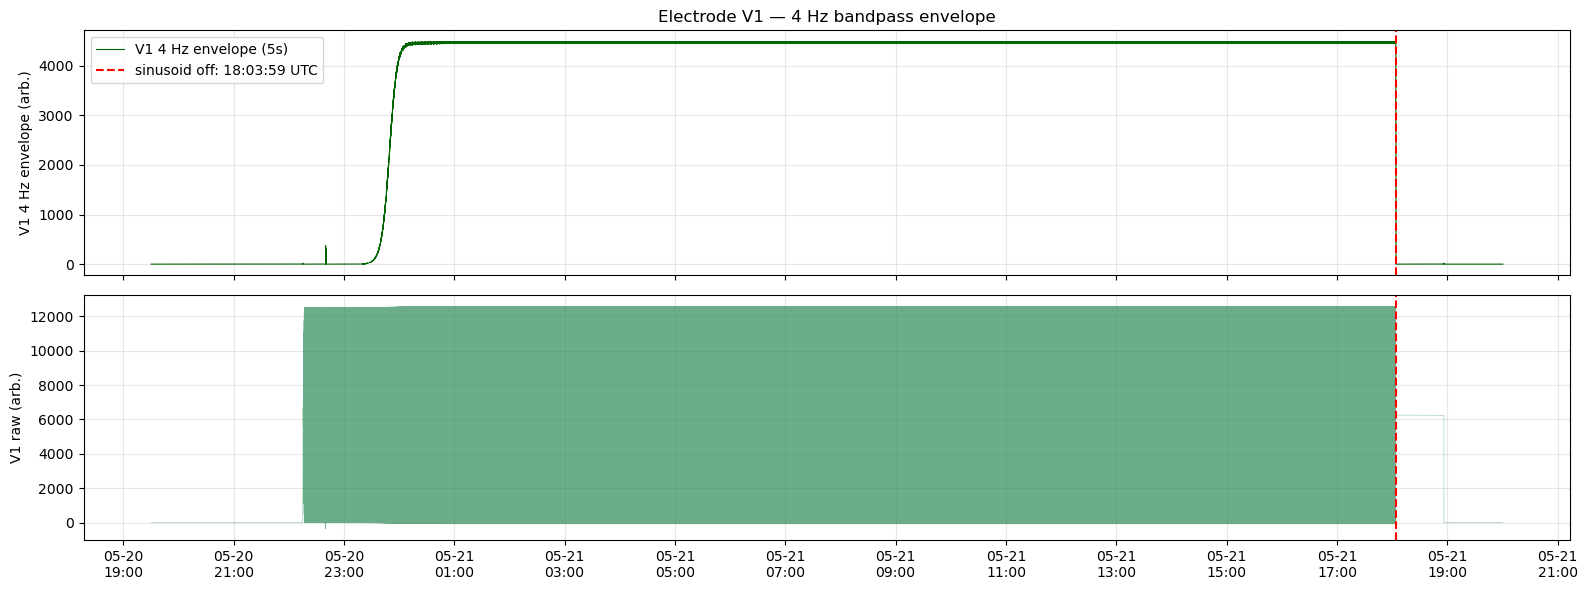

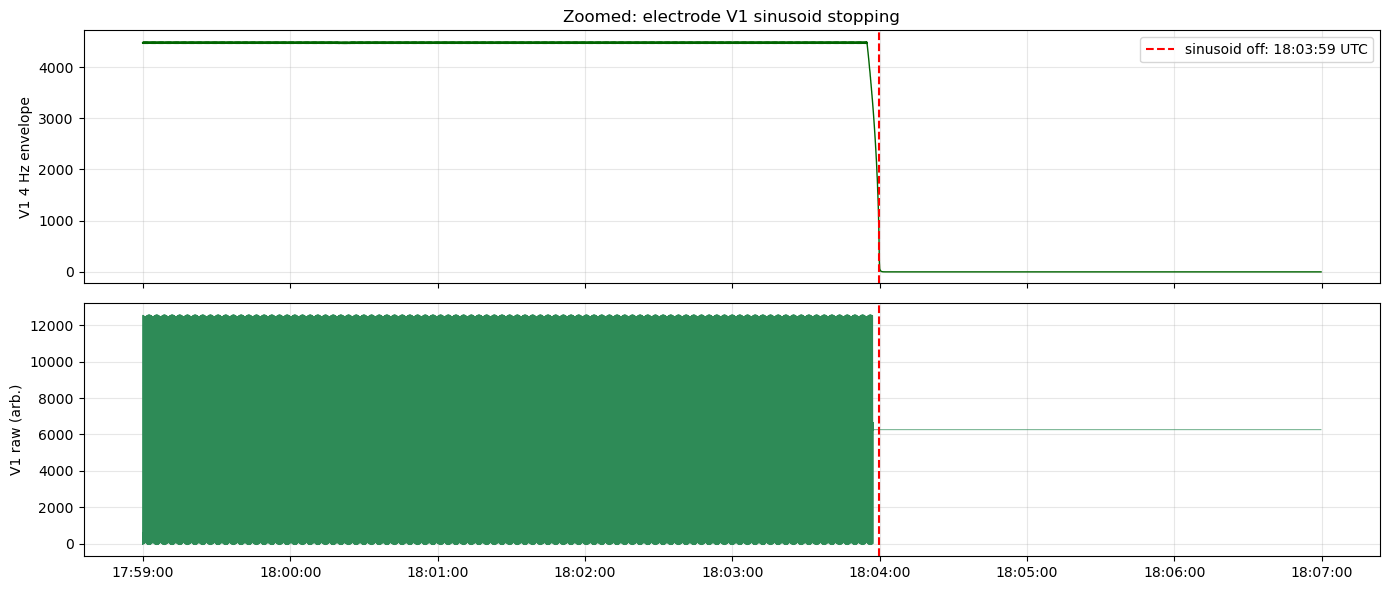

In [63]:
# Load electrode V1 at 64 Hz — preserves the 4 Hz sinusoidal drive
t_v1, y_v1 = load_channel(FILENAME_V1, fs_out=64.0)

# Isolate the 4 Hz drive component with a narrow bandpass, then take envelope
sos_el = butter(4, [2.0, 6.0], btype='bandpass', fs=64.0, output='sos')
y_v1_bp  = sosfiltfilt(sos_el, y_v1)
_win     = int(5 * 64)  # 5 s smoothing window
y_v1_env = np.sqrt(uniform_filter1d(y_v1_bp**2, size=_win))

# Drive-off: last sample where 4 Hz envelope > 10% of peak
env_thresh = 0.10 * y_v1_env.max()
driven_idx = np.where(y_v1_env > env_thresh)[0]
if len(driven_idx):
    drive_off_gps = t_v1[driven_idx[-1]]
    drive_off_dt  = gps_to_dt(drive_off_gps)
    print(f"Drive-off (sinusoid):  {drive_off_dt}  (GPS {drive_off_gps:.0f})")
else:
    print("Could not detect drive-off — adjust threshold")
    drive_off_dt = None

# ── Full overview ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
axes[0].plot([gps_to_dt(t) for t in t_v1], y_v1_env, linewidth=0.8,
             color='darkgreen', label='V1 4 Hz envelope (5s)')
if drive_off_dt:
    axes[0].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
                    label=f'sinusoid off: {drive_off_dt.strftime("%H:%M:%S")} UTC')
axes[0].set_ylabel('V1 4 Hz envelope (arb.)'); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[0].set_title('Electrode V1 — 4 Hz bandpass envelope')

axes[1].plot([gps_to_dt(t) for t in t_v1], y_v1, linewidth=0.3, color='seagreen', alpha=0.7)
if drive_off_dt:
    axes[1].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5)
axes[1].set_ylabel('V1 raw (arb.)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Zoomed: 10 min around drive-off ──────────────────────────────────────────
if drive_off_dt:
    zoom_gps0 = drive_off_gps - 5 * 60
    zoom_gps1 = drive_off_gps + 3 * 60
    zmask = (t_v1 >= zoom_gps0) & (t_v1 <= zoom_gps1)
    t_z = [gps_to_dt(t) for t in t_v1[zmask]]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(t_z, y_v1_env[zmask], linewidth=1.0, color='darkgreen')
    axes[0].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5,
                    label=f'sinusoid off: {drive_off_dt.strftime("%H:%M:%S")} UTC')
    axes[0].set_ylabel('V1 4 Hz envelope'); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
    axes[0].set_title('Zoomed: electrode V1 sinusoid stopping')

    axes[1].plot(t_z, y_v1[zmask], linewidth=0.5, color='seagreen')
    axes[1].axvline(drive_off_dt, color='red', linestyle='--', linewidth=1.5)
    axes[1].set_ylabel('V1 raw (arb.)')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    axes[1].xaxis.set_major_locator(mdates.MinuteLocator(interval=1))
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 5. Exponential Fit: Spindown Time
Fit f(t) = A · exp(−γt) to the cleanly decaying portion.  
- `F_MAX_FIT`: upper limit — exclude the plateau before the drive was off  
- `F_MIN_FIT`: lower limit — exclude noisy tail near zero  

τ = 1/γ is the 1/e spindown time.

In [69]:
# ── Choose which channel to fit ───────────────────────────────────────────────
USE_CHANNEL = 'PIT'   # YAW channel not working — use PIT
# ─────────────────────────────────────────────────────────────────────────────

if USE_CHANNEL == 'YAW':
    t_fit_all, freq_fit_all, env_fit_all = t_freq_yaw, freq_yaw, env_yaw
else:
    t_fit_all, freq_fit_all, env_fit_all = t_freq_pit, freq_pit, env_pit

# ── Adjust these based on the frequency and envelope plots ────────────────────
F_MAX_FIT   = 3.8    # Hz – just below the 4 Hz driven plateau
F_MIN_FIT   = 1.0    # Hz – fit only clean exponential region (3.8→1.0 Hz)
AMP_THRESH  = 0.15   # fraction of peak envelope — exclude low-amplitude points
T_SKIP_SEC  = 60     # seconds to skip at start (filter edge transient)
# ─────────────────────────────────────────────────────────────────────────────

amp_peak   = env_fit_all.max()
t_start    = t_fit_all[0] + T_SKIP_SEC

fit_mask = (
    (freq_fit_all > F_MIN_FIT) &
    (freq_fit_all < F_MAX_FIT) &
    (env_fit_all  > AMP_THRESH * amp_peak) &
    (t_fit_all    > t_start)
)

t_fit_gps = t_fit_all[fit_mask]
f_fit     = freq_fit_all[fit_mask]

print(f"Using: {USE_CHANNEL}  |  {len(f_fit)} points in fit region")
if len(f_fit) > 0:
    print(f"  {gps_to_dt(t_fit_gps[0])} → {gps_to_dt(t_fit_gps[-1])}")
    print(f"  span: {(t_fit_gps[-1] - t_fit_gps[0]) / 60:.1f} min")
    print(f"  freq range: {f_fit.min():.3f} – {f_fit.max():.3f} Hz")

Using: PIT  |  43493 points in fit region
  2026-05-21 18:07:23.757812+00:00 → 2026-05-21 18:19:23.273438+00:00
  span: 12.0 min
  freq range: 0.500 – 3.800 Hz


In [70]:
if len(f_fit) < 20:
    print("WARNING: too few points — adjust F_MIN_FIT / F_MAX_FIT or RING_START / RING_END")
else:
    t0  = t_fit_gps[0]
    t_s = t_fit_gps - t0  # seconds from start of fit region

    def exp_decay(t, A, gamma):
        return A * np.exp(-gamma * t)

    popt, pcov = curve_fit(exp_decay, t_s, f_fit,
                           p0=[f_fit[0], 1e-3], maxfev=10000)
    A_fit, gamma_fit = popt
    A_err, gamma_err = np.sqrt(np.diag(pcov))

    tau     = 1.0 / gamma_fit
    tau_err = gamma_err / gamma_fit**2

    print(f"=== Spindown Results ===")
    print(f"γ  = {gamma_fit:.6f} ± {gamma_err:.6f}  s⁻¹")
    print(f"τ  = {tau:.1f} ± {tau_err:.1f}  s")
    print(f"τ  = {tau/60:.2f} ± {tau_err/60:.2f}  min")
    print(f"A  = {A_fit:.4f} Hz  (extrapolated initial frequency)")

=== Spindown Results ===
γ  = 0.003234 ± 0.000001  s⁻¹
τ  = 309.3 ± 0.1  s
τ  = 5.15 ± 0.00  min
A  = 3.8165 Hz  (extrapolated initial frequency)


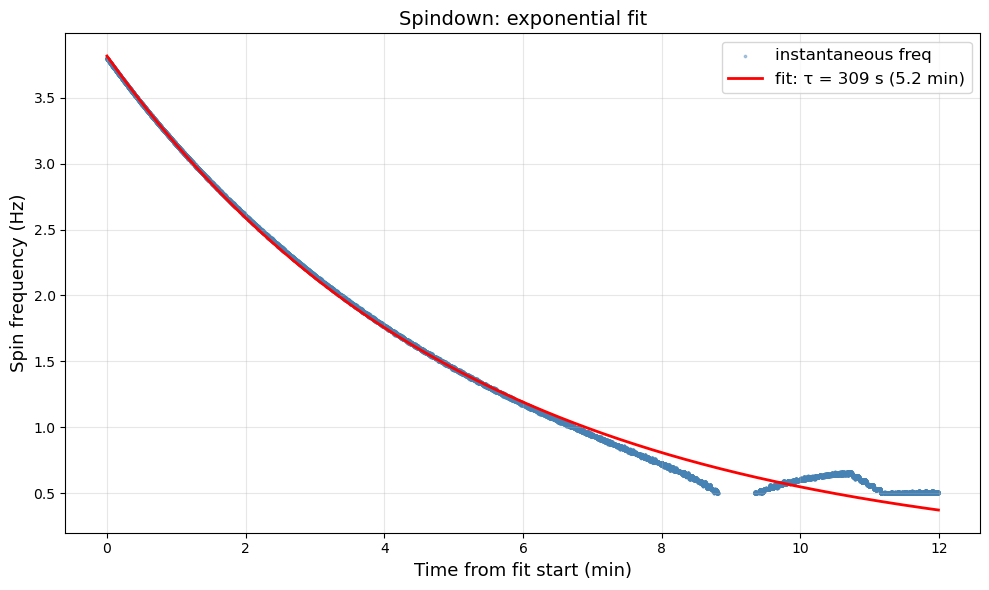

In [71]:
if len(f_fit) >= 20:
    t_curve = np.linspace(t_s[0], t_s[-1], 1000)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(t_s / 60, f_fit, s=3, alpha=0.4, color='steelblue', label='instantaneous freq')
    ax.plot(t_curve / 60, exp_decay(t_curve, *popt), 'r-', linewidth=2,
            label=f'fit: τ = {tau:.0f} s ({tau/60:.1f} min)')
    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('Spin frequency (Hz)', fontsize=13)
    ax.set_title('Spindown: exponential fit', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

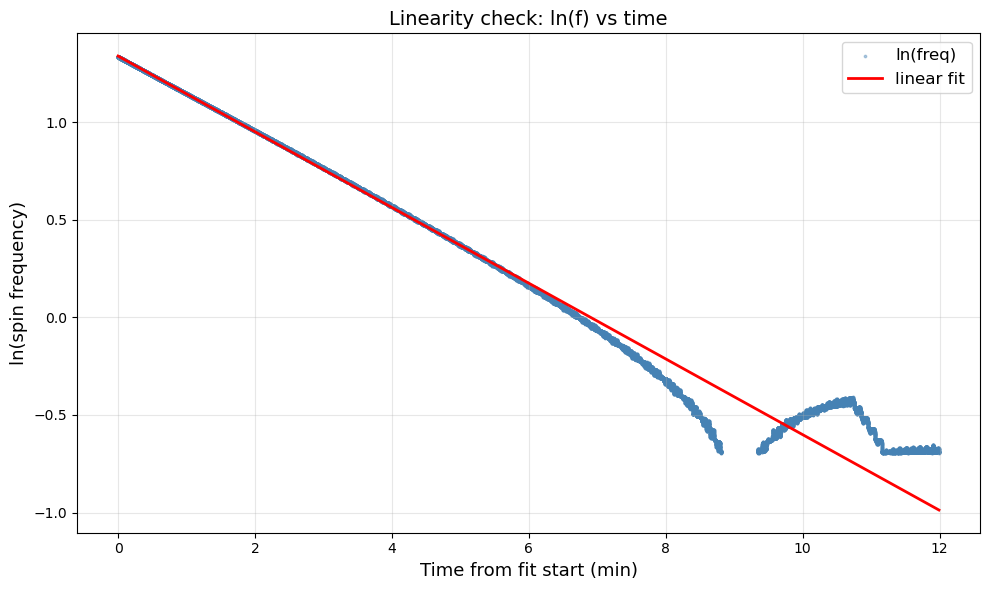

In [72]:
# Linearity check: ln(f) vs time should be a straight line for pure exponential decay
if len(f_fit) >= 20:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(t_s / 60, np.log(f_fit), s=3, alpha=0.4, color='steelblue', label='ln(freq)')
    ax.plot(t_curve / 60, np.log(exp_decay(t_curve, *popt)), 'r-', linewidth=2, label='linear fit')
    ax.set_xlabel('Time from fit start (min)', fontsize=13)
    ax.set_ylabel('ln(spin frequency)', fontsize=13)
    ax.set_title('Linearity check: ln(f) vs time', fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Results Summary

In [73]:
if len(f_fit) >= 20:
    print("=" * 40)
    print("SPINDOWN RESULTS")
    print("=" * 40)
    print(f"Decay constant:  γ = {gamma_fit:.6f} ± {gamma_err:.6f} s⁻¹")
    print(f"Spindown time:   τ = {tau:.1f} ± {tau_err:.1f} s")
    print(f"                   = {tau/60:.2f} ± {tau_err/60:.2f} min")
    print(f"Initial freq:    A = {A_fit:.4f} Hz")
    print(f"Fit region:      {F_MIN_FIT}–{F_MAX_FIT} Hz  ({len(f_fit)} points)")
    print(f"Smoothing:       {SMOOTH_SEC}s window")

SPINDOWN RESULTS
Decay constant:  γ = 0.003234 ± 0.000001 s⁻¹
Spindown time:   τ = 309.3 ± 0.1 s
                   = 5.15 ± 0.00 min
Initial freq:    A = 3.8165 Hz
Fit region:      0.5–3.8 Hz  (43493 points)
Smoothing:       30.0s window
